# Different Trajectories to acquire data

### Import and function Definition

In [1]:
# Import
import torch
from mrpro.data import KData, KTrajectory 
from mrpro.data.traj_calculators import KTrajectoryPulseq, KTrajectoryIsmrmrd
from mrpro.data.SpatialDimension import SpatialDimension
import matplotlib.pyplot as plt
import mrpro

# Local path
h5_path_cartesian = '/data/bouill01/goooo/20240801_cartesian_2D_256mm_256Nx_256Ny_15alpha/meas_MID00128_FID07024_20240801_cartesian_2D_256mm_256Nx_256Ny_15alpha.h5'
seq_path_cartesian = '/data/bouill01/goooo/20240801_cartesian_2D_256mm_256Nx_256Ny_15alpha/20240801_cartesian_2D_256mm_256Nx_256Ny_15alpha.seq'

h5_path_radial_uni = '/data/bouill01/0508/20240805_radial_2D_new_256mm_256spokes_uniform/meas_MID00077_FID07190_20240805_radial_2D_new_256mm_256spokes_uniform_with_traj.h5'
seq_path_radial_uni = '/data/bouill01/0508/20240805_radial_2D_new_256mm_256spokes_uniform/20240805_radial_2D_new_256mm_256spokes_uniform.seq'

h5_path_radial_gold = '/data/bouill01/0508/20240805_radial_2D_new_256mm_256spokes_golden_angle/meas_MID00078_FID07191_20240805_radial_2D_new_256mm_256spokes_golden_angle_with_traj.h5'
seq_path_radial_gold = '/data/bouill01/0508/20240805_radial_2D_new_256mm_256spokes_golden_angle/20240805_radial_2D_new_256mm_256spokes_golden_angle.seq'

h5_path_spiral = '/data/bouill01/goooo/20240801_spiral_2D_256mm_472k0_32interleaves_golden_angle_vds/meas_MID00125_FID07021_20240801_spiral_2D_256mm_472k0_32interleaves_golden_angle_vds_with_traj.h5'
seq_path_spiral = '/data/bouill01/goooo/20240801_spiral_2D_256mm_472k0_32interleaves_golden_angle_vds/20240801_spiral_2D_256mm_472k0_32interleaves_golden_angle_vds.seq'

def shift_k_space_trajectory(kdatapuls):
    # Extract k-space trajectory from kdatapuls
    ky_pulseq = kdatapuls.traj.ky
    kx_pulseq = kdatapuls.traj.kx
    kz_pulseq = kdatapuls.traj.kz

    # Number of indices
    num_indices = ky_pulseq.shape[2]

    # Initialize lists to store shifted trajectories
    shifted_ky = ky_pulseq.clone()
    shifted_kx = kx_pulseq.clone()

    # Loop to apply the shift to each index
    for i in range(num_indices-1):
        # Calculate the shift for the current index
        shifted_ky[:,:,i,:] -= ky_pulseq[:,:,i,0]
        shifted_kx[:,:,i,:] -= kx_pulseq[:,:,i,0]

    # Create shifted KTrajectory object
    shifted_traj = KTrajectory(kx=shifted_kx, ky=shifted_ky, kz=kz_pulseq)
    # Create shifted KData object
    shifted_kdatapuls = KData(data=kdatapuls.data, traj=shifted_traj, header=kdatapuls.header)

    return shifted_kdatapuls

def shift_rad_k__space_trajectory(kdatapuls):
    # Extract k-space trajectory from kdatapuls
    ky_pulseq = kdatapuls.traj.ky
    kx_pulseq = kdatapuls.traj.kx
    kz_pulseq = kdatapuls.traj.kz

    # Number of indices
    num_indices = ky_pulseq.shape[2]

    # Initialize lists to store shifted trajectories
    shifted_ky = ky_pulseq.clone()
    shifted_kx = kx_pulseq.clone()

    # Loop to apply the shift to each index
    for i in range(num_indices-1):
        # Calculate the shift for the current index
        shifted_ky[:,:,i,:] -= ky_pulseq[:,:,i,128]
        shifted_kx[:,:,i,:] -= kx_pulseq[:,:,i,128]

    # Create shifted KTrajectory object
    shifted_traj = KTrajectory(kx=shifted_kx, ky=shifted_ky, kz=kz_pulseq)
    # Create shifted KData object
    shifted_kdatapuls = KData(data=kdatapuls.data, traj=shifted_traj, header=kdatapuls.header)

    return shifted_kdatapuls

### Cartesian 2D

/data/bouill01/conda_envs/py311/lib/python3.11/site-packages/torch/functional.py:512: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3587.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


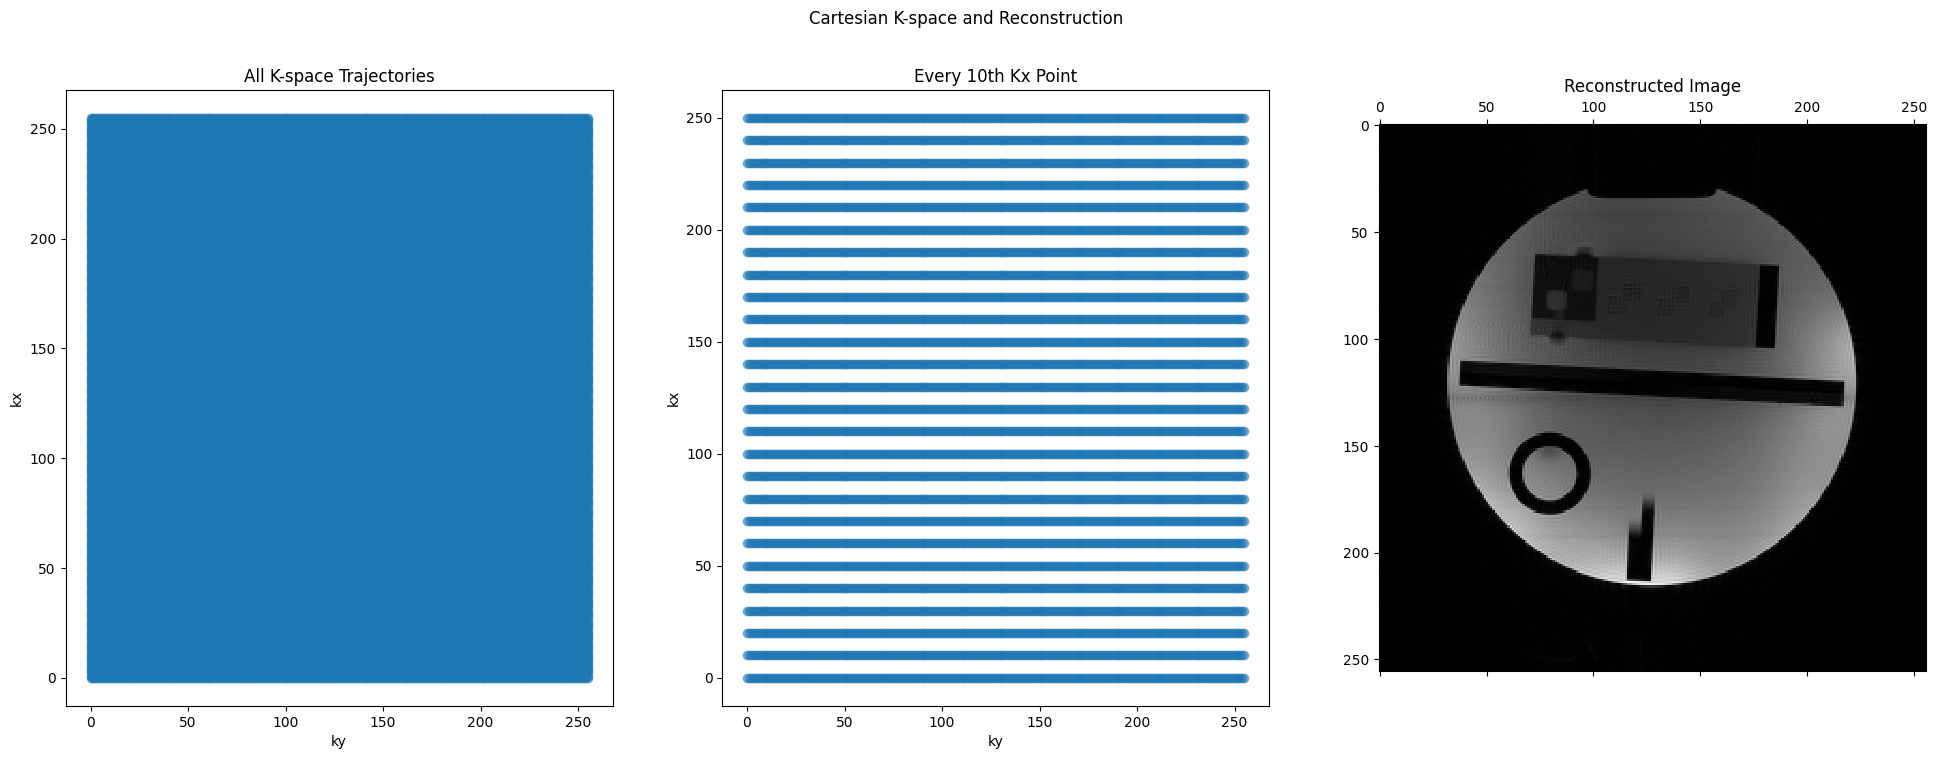

In [2]:
# Load data from ISMRMRD file using KTrajectoryIsmrmrd
kdatapuls = KData.from_file(h5_path_cartesian, KTrajectoryPulseq(seq_path=seq_path_cartesian))
kdatapuls.header.recon_matrix = SpatialDimension(z=1, y=256, x=256)

# Perform the reconstruction
reconstructionpuls = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdatapuls)
# Use this to run on GPU: kdata = kdata.cuda()
img = reconstructionpuls(kdatapuls)

# Display the reconstructed image
# If there are multiple slices, only the first one is selected
first_img = img.rss().cpu()[0, 0, :, :]  # images, z, y, x

# Create a figure with three subplots: one for all trajectories, one for every 10th kx, and one for the image
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
fig.suptitle('Cartesian K-space and Reconstruction')

# Plot all k-space trajectories
ax1 = axes[0]
# Create grid
kx_grid, ky_grid = torch.meshgrid(torch.arange(256), torch.arange(256))

# Flatten and plot all k-space trajectories
ax1.plot(ky_grid.flatten().numpy(), kx_grid.flatten().numpy(), 'o', alpha=0.5)
ax1.set_xlabel('ky')
ax1.set_ylabel('kx')
ax1.set_title('All K-space Trajectories')

# Plot k-space trajectories with every 10th point in kx
ax2 = axes[1]
# Sample every 10th point in kx dimension, keeping all ky points
sample_rate_kx = 10
kx_sampled = kx_grid[::sample_rate_kx, :]
ky_sampled = ky_grid[::sample_rate_kx, :]

# Flatten and plot
ax2.plot(ky_sampled.flatten().numpy(), kx_sampled.flatten().numpy(), 'o', alpha=0.5)
ax2.set_xlabel('ky')
ax2.set_ylabel('kx')
ax2.set_title('Every 10th Kx Point')

# Plot the reconstructed image
ax3 = axes[2]
ax3.matshow(first_img, cmap='gray')
ax3.set_title('Reconstructed Image')

# Display the combined figure
plt.show()


### Radial Uniform

Calculating for single us_idx: tensor([[  0,   4,   8,  12,  16,  20,  24,  28,  32,  36,  40,  44,  48,  52,
          56,  60,  64,  68,  72,  76,  80,  84,  88,  92,  96, 100, 104, 108,
         112, 116, 120, 124, 128]])


/tmp/ipykernel_10887/1530372766.py:52: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


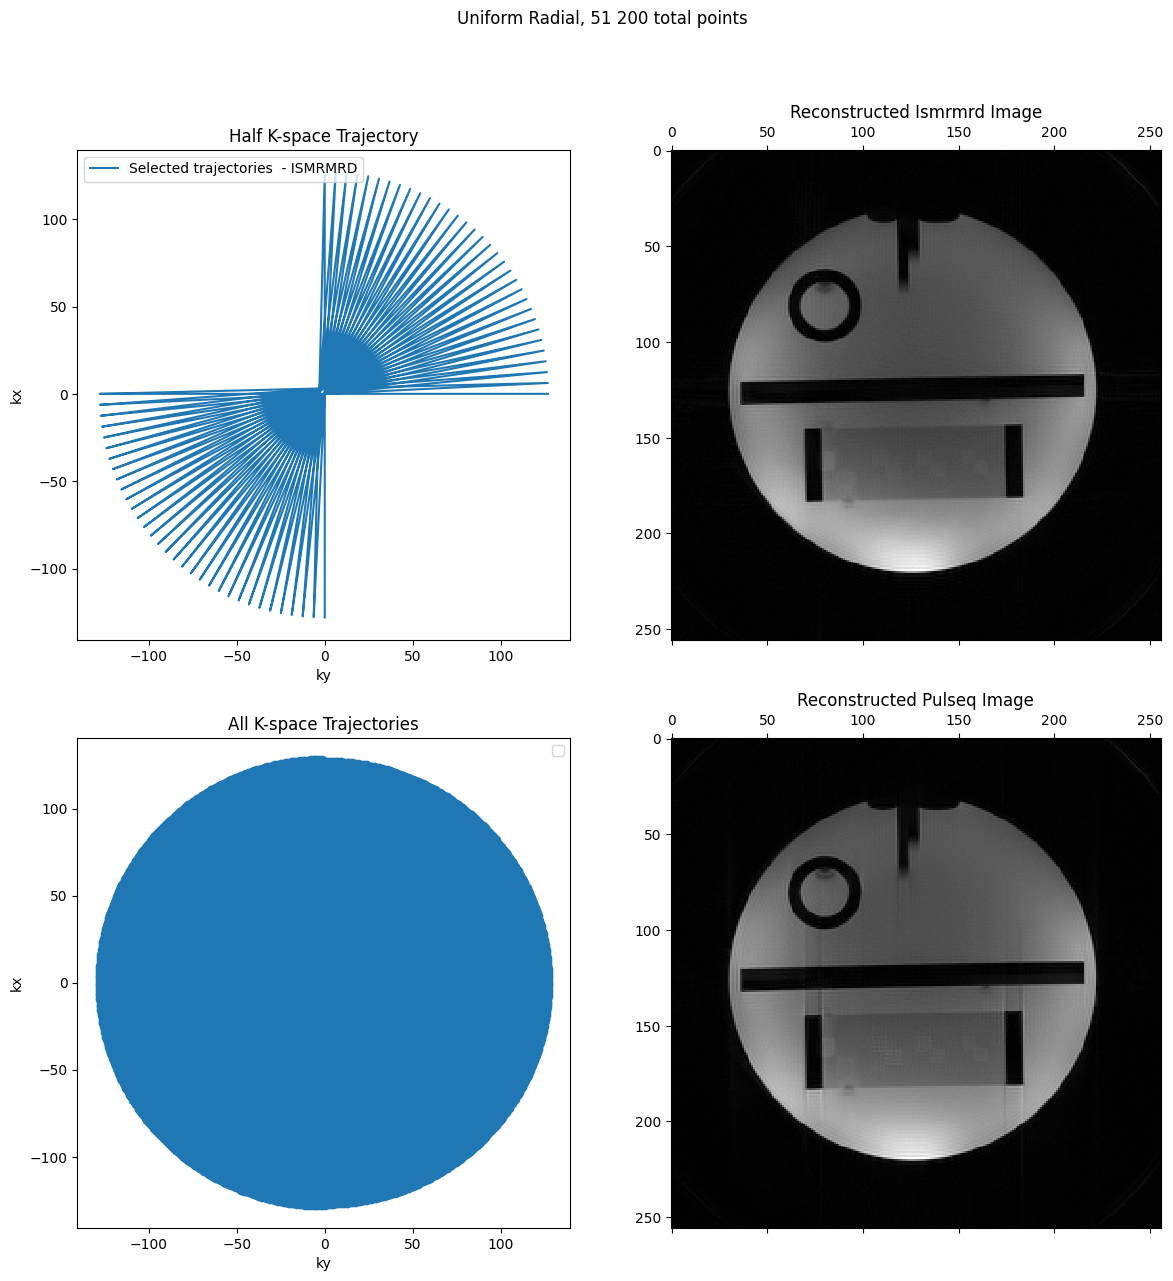

In [3]:
# Load data from ISMRMRD file using KTrajectoryIsmrmrd
kdatapuls = KData.from_file(h5_path_radial_uni, KTrajectoryPulseq(seq_path=seq_path_radial_uni))

shiftedkdata = shift_rad_k__space_trajectory(kdatapuls)

kdata_ismrmrd = KData.from_file(h5_path_radial_gold, KTrajectoryIsmrmrd())
# Perform the reconstruction
reconstruction_puls = mrpro.algorithms.reconstruction.IterativeSenseReconstruction.from_kdata(kdatapuls, n_max_iter=10)
img = reconstruction_puls(kdatapuls)

# Display the reconstructed image
# If there are multiple slices, only the first one is selected
first_img = torch.abs(img.data[0, 0, 0, :, :])  # images, z, y, x

# Perform the reconstruction
reconstruction_shiftpuls = mrpro.algorithms.reconstruction.IterativeSenseReconstruction.from_kdata(kdata_ismrmrd, n_max_iter=10)
ism_img = reconstruction_shiftpuls(kdata_ismrmrd)

# Display the reconstructed image
# If there are multiple slices, only the first one is selected
ismrmrd_img = torch.abs(ism_img.data[0, 0, 0, :, :])  # images, z, y, x

# Define values to compare for us_idx
us_idx_values = [torch.arange(0, 129, 4 )[None, :]]

# Create a figure with three subplots: one for a single trajectory, one for all trajectories, and one for the image
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
fig.suptitle('Uniform Radial, 51 200 total points')
# Plot a single k-space trajectory for the first us_idx value on the first subplot
ax1 = axes[0,0]
single_us_idx = us_idx_values[0]
print(f"Calculating for single us_idx:", single_us_idx)

# Split k-space data into other dimensions based on undersampling indices
kdata_us_single = KData.split_k1_into_other(shiftedkdata, single_us_idx, other_label='repetition')

# Plot single k-space trajectory for ISMRMRD
ax1.plot(kdata_us_single.traj.ky.flatten(), kdata_us_single.traj.kx.flatten(), '-', label='Selected trajectories  - ISMRMRD')
ax1.set_xlabel('ky')
ax1.set_ylabel('kx')
ax1.set_title('Selected K-space Trajectories')
ax1.legend()

# Plot k-space trajectories for all us_idx values on the second subplot
ax2 = axes[1,0]
# Plot k-space trajectory for ISMRMRD
ax2.plot(shiftedkdata.traj.ky.flatten(), shiftedkdata.traj.kx.flatten(), 'o')

ax2.set_xlabel('ky')
ax2.set_ylabel('kx')
ax2.set_title('All K-space Trajectories')
ax2.legend()

# Plot the reconstructed image on the third subplot
ax3 = axes[0,1]
ax3.matshow(ismrmrd_img, cmap='gray')
ax3.set_title('Reconstructed Ismrmrd Image')

# Plot the reconstructed image on the third subplot
ax4 = axes[1,1]
ax4.matshow(first_img, cmap='gray')
ax4.set_title('Reconstructed Pulseq Image')

# Display the combined figure
plt.show()

### Radial Golden Angle

Calculating for single us_idx: tensor([[ 1,  5,  9, 13, 17, 21, 25, 29, 33, 37, 41, 45, 49, 53, 57, 61, 65, 69,
         73, 77, 81, 85, 89, 93, 97]])


/tmp/ipykernel_10887/4008727831.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


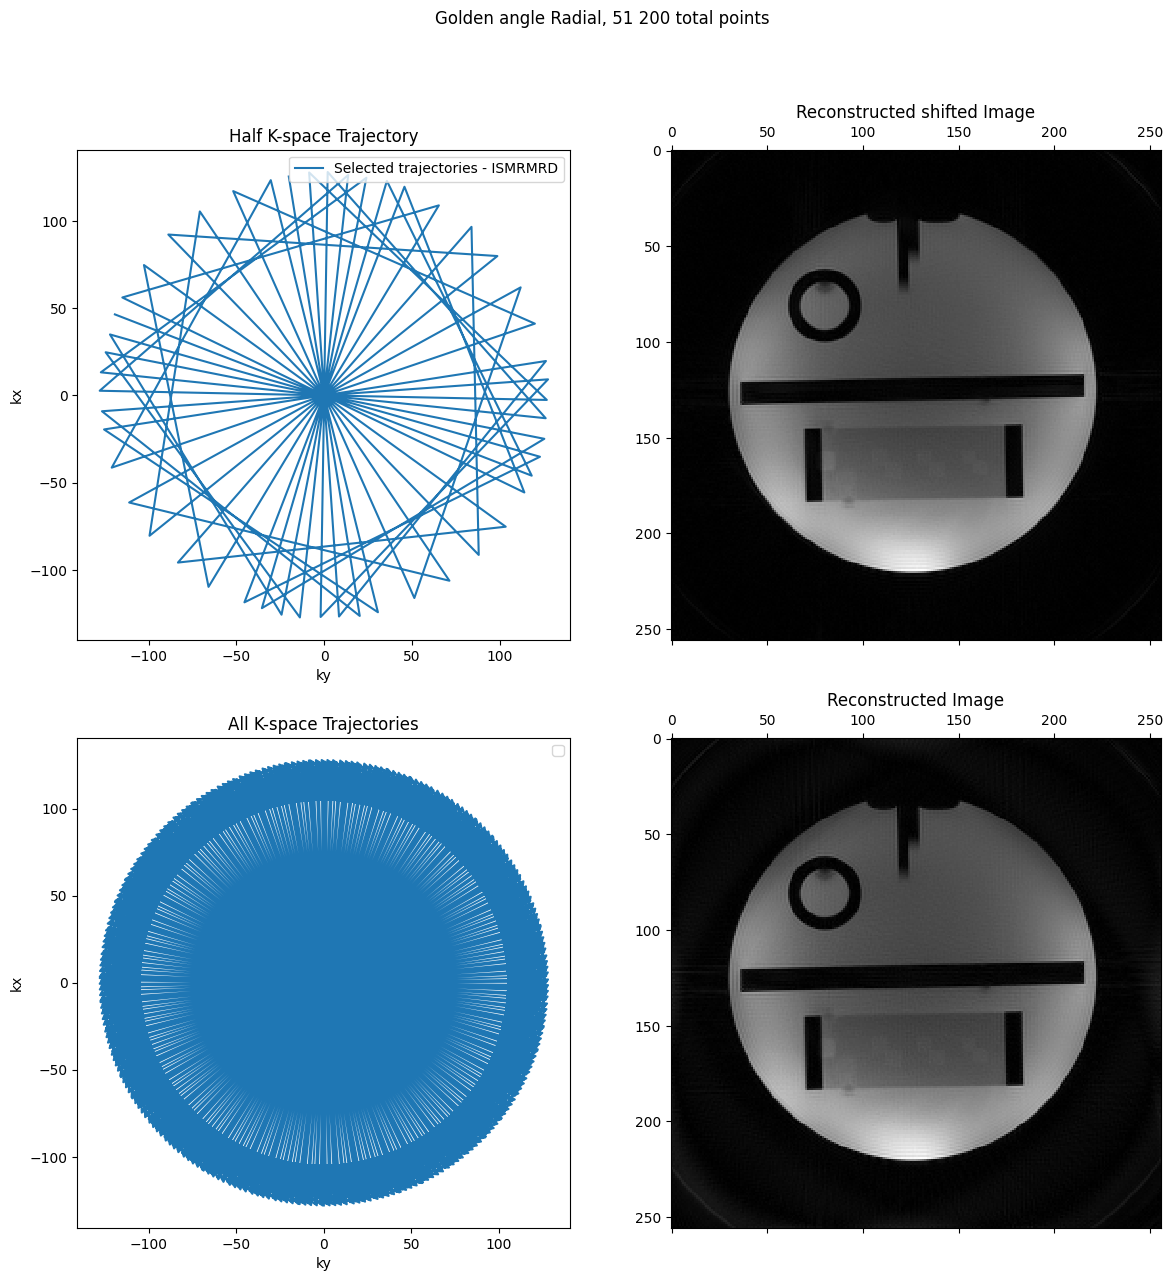

In [4]:
# Load data from ISMRMRD file using KTrajectoryIsmrmrd
kdatapuls = KData.from_file(h5_path_radial_gold, KTrajectoryPulseq(seq_path=seq_path_radial_gold))

shiftedkdata = shift_rad_k__space_trajectory(kdatapuls)

# Perform the reconstruction
reconstruction_puls = mrpro.algorithms.reconstruction.IterativeSenseReconstruction.from_kdata(kdatapuls, n_max_iter=10)
img = reconstruction_puls(kdatapuls)

# Display the reconstructed image
# If there are multiple slices, only the first one is selected
first_img = torch.abs(img.data[0, 0, 0, :, :])  # images, z, y, x

# Perform the reconstruction
reconstruction_shiftpuls = mrpro.algorithms.reconstruction.IterativeSenseReconstruction.from_kdata(shiftedkdata, n_max_iter=10)
shiftimg = reconstruction_shiftpuls(shiftedkdata)

# Display the reconstructed image
# If there are multiple slices, only the first one is selected
shift_img = torch.abs(shiftimg.data[0, 0, 0, :, :])  # images, z, y, x

# Define values to compare for us_idx
us_idx_values = [torch.arange(1, 100, 4)[None, :]]

# Create a figure with three subplots: one for a single trajectory, one for all trajectories, and one for the image
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
fig.suptitle('Golden angle Radial, 51 200 total points')
# Plot a single k-space trajectory for the first us_idx value on the first subplot
ax1 = axes[0,0]
single_us_idx = us_idx_values[0]
print(f"Calculating for single us_idx:", single_us_idx)

# Split k-space data into other dimensions based on undersampling indices
kdata_us_single = KData.split_k1_into_other(shiftedkdata, single_us_idx, other_label='repetition')

# Plot single k-space trajectory for ISMRMRD
ax1.plot(kdata_us_single.traj.ky.flatten(), kdata_us_single.traj.kx.flatten(), '-', label='Selected trajectories - ISMRMRD')
ax1.set_xlabel('ky')
ax1.set_ylabel('kx')
ax1.set_title('Half K-space Trajectory')
ax1.legend()

# Plot k-space trajectories for all us_idx values on the second subplot
ax2 = axes[1,0]
# Plot k-space trajectory for ISMRMRD
ax2.plot(shiftedkdata.traj.ky.flatten(), shiftedkdata.traj.kx.flatten(), '-')

ax2.set_xlabel('ky')
ax2.set_ylabel('kx')
ax2.set_title('All K-space Trajectories')
ax2.legend()

# Plot the reconstructed image on the third subplot
ax3 = axes[0,1]
ax3.matshow(shift_img, cmap='gray')
ax3.set_title('Reconstructed shifted Image')

# Plot the reconstructed image on the third subplot
ax4 = axes[1,1]
ax4.matshow(first_img, cmap='gray')
ax4.set_title('Reconstructed Image')

# Display the combined figure
plt.show()

### Spiral 2D

Calculating for single us_idx: tensor([[0]])


/tmp/ipykernel_10887/2622699844.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


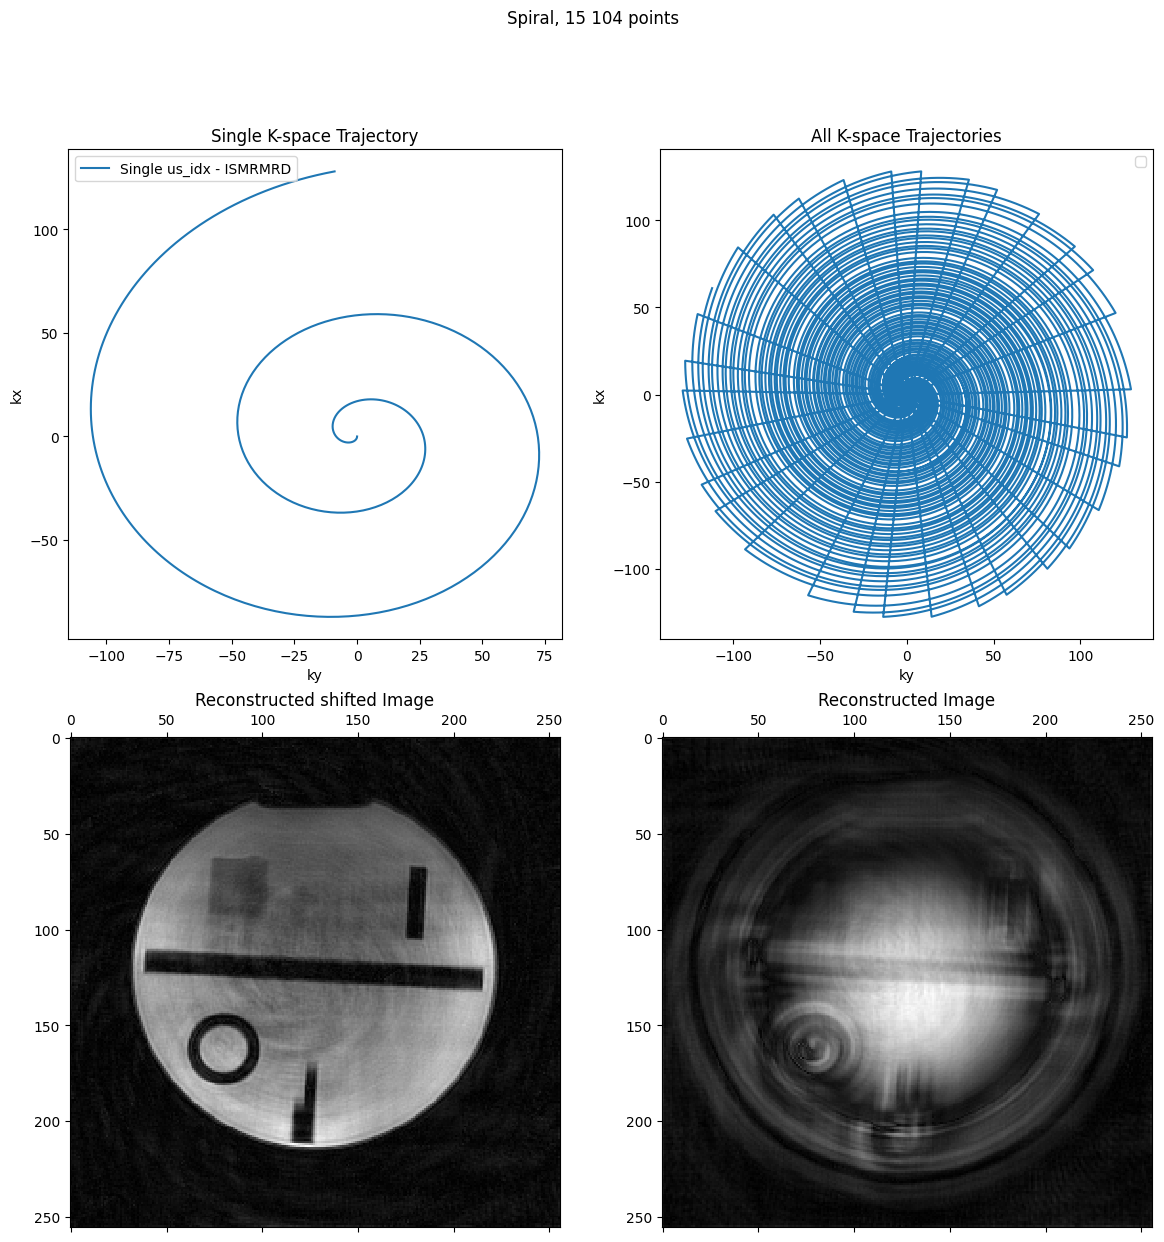

In [5]:
# Load data from ISMRMRD file using KTrajectoryIsmrmrd
kdatapuls = KData.from_file(h5_path_spiral, KTrajectoryPulseq(seq_path=seq_path_spiral))

shiftedkdata = shift_k_space_trajectory(kdatapuls)

# Perform the reconstruction
reconstruction_puls = mrpro.algorithms.reconstruction.IterativeSenseReconstruction.from_kdata(kdatapuls, n_max_iter=10)
img = reconstruction_puls(kdatapuls)

# Display the reconstructed image
# If there are multiple slices, only the first one is selected
first_img = torch.abs(img.data[0, 0, 0, :, :])  # images, z, y, x

# Perform the reconstruction
reconstruction_shiftpuls = mrpro.algorithms.reconstruction.IterativeSenseReconstruction.from_kdata(shiftedkdata, n_max_iter=10)
shiftimg = reconstruction_shiftpuls(shiftedkdata)

# Display the reconstructed image
# If there are multiple slices, only the first one is selected
shift_img = torch.abs(shiftimg.data[0, 0, 0, :, :])  # images, z, y, x

# Define values to compare for us_idx
us_idx_values = [torch.arange(0, 8, 10 )[None, :]]

# Create a figure with three subplots: one for a single trajectory, one for all trajectories, and one for the image
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
fig.suptitle('Spiral, 15 104 points')
# Plot a single k-space trajectory for the first us_idx value on the first subplot
ax1 = axes[0,0]
single_us_idx = us_idx_values[0]
print(f"Calculating for single us_idx:", single_us_idx)

# Split k-space data into other dimensions based on undersampling indices
kdata_us_single = KData.split_k1_into_other(shiftedkdata, single_us_idx, other_label='repetition')

# Plot single k-space trajectory for ISMRMRD
ax1.plot(kdata_us_single.traj.ky.flatten(), kdata_us_single.traj.kx.flatten(), '-', label='Single us_idx - ISMRMRD')
ax1.set_xlabel('ky')
ax1.set_ylabel('kx')
ax1.set_title('Single K-space Trajectory')
ax1.legend()

# Plot k-space trajectories for all us_idx values on the second subplot
ax2 = axes[0,1]
# Plot k-space trajectory for ISMRMRD
ax2.plot(shiftedkdata.traj.ky.flatten(), shiftedkdata.traj.kx.flatten(), '-')

ax2.set_xlabel('ky')
ax2.set_ylabel('kx')
ax2.set_title('All K-space Trajectories')
ax2.legend()

# Plot the reconstructed image on the third subplot
ax3 = axes[1,0]
ax3.matshow(shift_img, cmap='gray')
ax3.set_title('Reconstructed shifted Image')

# Plot the reconstructed image on the third subplot
ax4 = axes[1,1]
ax4.matshow(first_img, cmap='gray')
ax4.set_title('Reconstructed Image')

# Display the combined figure
plt.show()